# Librerias

In [156]:
import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Carga y Preprocesamiento

In [157]:
def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

def load_mnist_dataset(mnist_path):
    x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
    y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))
    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]
    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]
    x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
    y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))
    return x_train, y_train, x_val, y_val, x_test, y_test

def scale(x_mean, x_std, x_data):
    return (x_data - x_mean) / x_std

x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('mnist/')

x_train = x_train.reshape(50000, -1).astype(np.float32)
y_train = y_train.flatten().astype(np.int64)
x_val = x_val.reshape(10000, -1).astype(np.float32)
y_val = y_val.flatten().astype(np.int64)
x_test = x_test.reshape(10000, -1).astype(np.float32)
y_test = y_test.flatten().astype(np.int64)

x_mean, x_std = x_train.mean(), x_train.std()
x_train = scale(x_mean, x_std, x_train)
x_val = scale(x_mean, x_std, x_val)
x_test = scale(x_mean, x_std, x_test)

device = torch.device("mps" if torch.mps.is_available() else "cpu")


# Training loop

In [158]:
def training(model, train_loader, val_loader, optimizer, criterion, epochs):
    history = {'train_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            pbar.set_postfix(cost=f"{loss.item():.4f}")
        
        model.eval()
        correct, total = 0, 0
        val_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                val_loss += criterion(outputs, y).item()
                _, predicted = torch.max(outputs, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()
        
        acc = correct / total
        history['train_loss'].append(running_loss / len(train_loader))
        history['val_acc'].append(acc)
        
        print(f"Cost: {history['train_loss'][-1]:.4f}, Val Accuracy: {acc:.4f}")
    
    return history

# Modelos

In [159]:
criterion = nn.CrossEntropyLoss()
results = []
epocas= 30

In [160]:
print("\nMODELO 1  (200 neuronas, Adam, LR 0.001)")
model1 = nn.Sequential(
    nn.Linear(784, 200),
    nn.ReLU(),
    nn.Linear(200, 10)
).to(device)

opt1 = optim.Adam(model1.parameters(), lr=0.001)
loader1 = DataLoader(
    TensorDataset(
        torch.from_numpy(x_train),
        torch.from_numpy(y_train)),
        batch_size=128, 
        shuffle=True)

val_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(x_val), 
        torch.from_numpy(y_val)), 
        batch_size=128)

h1 = training(model1, loader1, val_loader, opt1, criterion, epocas)
results.append((model1, h1['val_acc'][-1], "MODELO 1"))


MODELO 1  (200 neuronas, Adam, LR 0.001)


Epoch 1/30: 100%|██████████| 391/391 [00:01<00:00, 262.60it/s, cost=0.1274]


Cost: 0.3053, Val Accuracy: 0.9544


Epoch 2/30: 100%|██████████| 391/391 [00:01<00:00, 296.45it/s, cost=0.1184]


Cost: 0.1309, Val Accuracy: 0.9694


...

Cost: 0.0072, Val Accuracy: 0.9804


Epoch 29/30: 100%|██████████| 391/391 [00:01<00:00, 355.48it/s, cost=0.0002]


Cost: 0.0078, Val Accuracy: 0.9781


Epoch 30/30: 100%|██████████| 391/391 [00:01<00:00, 289.87it/s, cost=0.0001]


Cost: 0.0070, Val Accuracy: 0.9791


In [161]:
print("\nMODELO 2:(512 -> 256 neuronas, Adam, LR 0.001)")
model2 = nn.Sequential(
    nn.Linear(784, 512), 
    nn.ReLU(),
    nn.Linear(512, 256), 
    nn.ReLU(),
    nn.Linear(256, 10)
).to(device)

opt2 = optim.Adam(model2.parameters(), lr=0.001)

loader2 = DataLoader(
    TensorDataset(
        torch.from_numpy(x_train),
        torch.from_numpy(y_train)), 
        batch_size=64, 
        shuffle=True)

h2 = training(model2, loader2, val_loader, opt2, criterion, epocas)
results.append((model2, h2['val_acc'][-1], "MODELO 2"))


MODELO 2:(512 -> 256 neuronas, Adam, LR 0.001)


Epoch 1/30: 100%|██████████| 782/782 [00:02<00:00, 284.61it/s, cost=0.0479]


Cost: 0.2197, Val Accuracy: 0.9675


Epoch 2/30: 100%|██████████| 782/782 [00:02<00:00, 311.55it/s, cost=0.0446]


Cost: 0.0929, Val Accuracy: 0.9721


...

Cost: 0.0079, Val Accuracy: 0.9796


Epoch 29/30: 100%|██████████| 782/782 [00:02<00:00, 313.98it/s, cost=0.0009]


Cost: 0.0110, Val Accuracy: 0.9776


Epoch 30/30: 100%|██████████| 782/782 [00:02<00:00, 313.30it/s, cost=0.0001]


Cost: 0.0117, Val Accuracy: 0.9795


In [162]:
print("\n MODELO 3 SGD (LR 0.01, Batch 256)")
model3 = nn.Sequential(
    nn.Linear(784, 200), 
    nn.ReLU(), 
    nn.Linear(200, 10)
).to(device)

opt3 = optim.SGD(model3.parameters(), lr=0.01)

loader3 = DataLoader(
    TensorDataset(
        torch.from_numpy(x_train), 
        torch.from_numpy(y_train)), 
        batch_size=64, 
        shuffle=True)

h3 = training(model3, loader3, val_loader, opt3, criterion, epocas)
results.append((model3, h3['val_acc'][-1], "MODELO 3"))


 MODELO 3 SGD (LR 0.01, Batch 256)


Epoch 1/30: 100%|██████████| 782/782 [00:01<00:00, 596.13it/s, cost=0.7936]


Cost: 0.6262, Val Accuracy: 0.9128


Epoch 2/30: 100%|██████████| 782/782 [00:01<00:00, 615.24it/s, cost=0.0475]


Cost: 0.3157, Val Accuracy: 0.9260


...

Cost: 0.0547, Val Accuracy: 0.9758


Epoch 29/30: 100%|██████████| 782/782 [00:01<00:00, 575.79it/s, cost=0.3156]


Cost: 0.0530, Val Accuracy: 0.9758


Epoch 30/30: 100%|██████████| 782/782 [00:01<00:00, 551.49it/s, cost=0.0189]


Cost: 0.0507, Val Accuracy: 0.9755


# Evaluacion

In [163]:
best_model, best_acc, name = max(results, key=lambda x: x[1])
print(f"\nEl mejor modelo fue {name} con Accuracy de Val: {best_acc:.4f}")

best_model.eval()
test_loader = DataLoader(TensorDataset(torch.from_numpy(x_test), torch.from_numpy(y_test)), batch_size=128)
test_correct, test_loss = 0, 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        outputs = best_model(x)
        test_loss += criterion(outputs, y).item()
        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == y).sum().item()

print(f"\nEVALUACION FINAL")
print(f"Test Loss: {test_loss/len(test_loader):.4f}")
print(f"Test Accuracy: {100 * test_correct / len(x_test):.2f}%")


El mejor modelo fue MODELO 2 con Accuracy de Val: 0.9795

EVALUACION FINAL
Test Loss: 0.1217
Test Accuracy: 98.16%


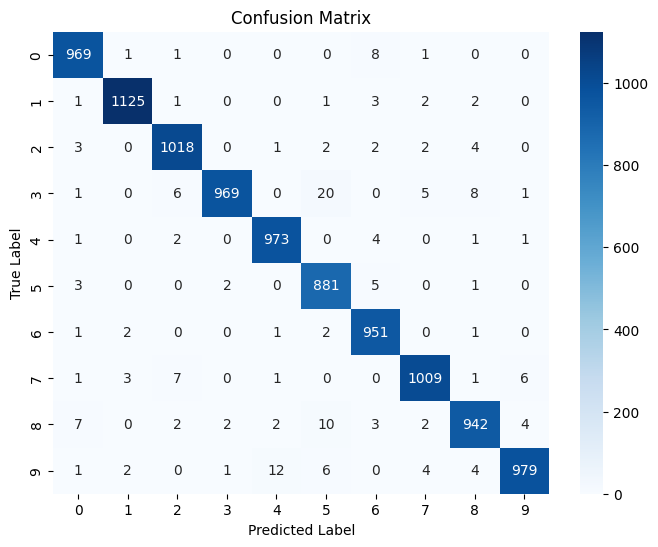

In [164]:
x_test_tensor = torch.from_numpy(x_test).float().to(device)
with torch.no_grad():
    test_scores = best_model(x_test_tensor)
y_pred = test_scores.argmax(dim=1).cpu().numpy()
conf_matrix = np.zeros((10, 10), dtype=int)
for true_label, pred_label in zip(y_test.squeeze(), y_pred.squeeze()):
    conf_matrix[true_label, pred_label] += 1
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[str(i) for i in range(10)], 
            yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Conclusion

Para esta practica realize 3 modelos, probando el aprendizaje de cada uno en del dataset de MNIST. El primero fue un modelo sencillo utlizando 2 capas y el optimizador de adam, el segundo fue uno mas complejo utilizando 3 capas y mayor cantidad de neuronas usando el mismo optimizador, mientras que el tercer modelo fue similar al primero pero ahora usando SGD. Como resultado los 3 llegaron a resultados muy similares utilizando 30 epocas, aunque el segundo mas complejo llego a un resultado ligeramente mejor. Pero al reducir la cantidad de epocas a 10, se puede notar como el primer modelo llega a mejores resultados en menor tiempo. Por lo que para este problema tal vez seria mas eficiente utilizar un modelo mas simple durante menos tiempo. 